# Project 3: Classification__

### __Objective__
In this lab, you will apply supervised learning (classification) models to predict one of the following
1. **Loan Approval Outcomes** : The dataset includes demographic, financial, and credit history features of loan applicants.
2. **Airline Passenger Satisfaction** : Customer satisfaction scores from 120,000+ airline passengers, including additional information about each passenger, their flight, and type of travel, as well as ther evaluation of different factors like cleanliness, comfort, service, and overall experience.
3. **Hotel Booking Cancellations** : booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces, among other things

### __Requirements__
Your task is to explore the data, clean and preprocess it appropriately, and build predictive models. Specifically, you must:
1. **Perform EDA**: Explore distributions, identify missing values, and check for class imbalance in the target variable.
2. **Preprocess the Data**: Handle categorical encodings, impute missing values, and scale your features. *Hint: Make sure to perform your train-test split BEFORE scaling to prevent data leakage!*
3. **Train Classification Models**: train **two** classification models (**Logistic Regression** and **KNN**).
5. **Evaluate & Compare**: Evaluate models using accuracy, precision, recall, F1-score, and confusion matrices. 

### __Deliverables__
You are expected to document your workflow using Markdown cells. Do not just write code; explain your **rationale**. Include insights from your EDA, justify your preprocessing decisions, and conclude with a comparative analysis discussing which of the three models performed best and why.

---

## __Data Dictionary__

___Copy you assigned dataset's dictionary from the guidleines___

---

## Setup and Data Loading
Import your libraries and load the dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

# Add your sklearn imports here...
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


In [2]:
# Load the dataset
# df = pd.read_csv('...')
df = pd.read_csv('./data/airline_passenger_satisfaction.csv',index_col=0)

# df.head()
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,male,48,First-time,business,Business,821 miles,2 minutes,5.0 minutes,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,FEMALE,35,returning,Business,Business,821 miles,26 minutes,39.0 minutes,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853 miles,0 minutes,0.0 minutes,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,business,Business,1905 miles,0 minutes,0.0 minutes,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,returning,business,Business,3470 miles,0 minutes,1.0 minutes,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## Part 1: Exploratory Data Analysis (EDA)
* What insights did you gain from your EDA? Are there missing values? Outliers? Is the target variable balanced or imbalanced? Use visualizations to support your findings.

In [3]:
# Your EDA code here 
# Note: you are not required to answer in this single cell, create more cells if needed
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136374 entries, 0 to 136373
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   ID                                      136374 non-null  int64
 1   Gender                                  136374 non-null  str  
 2   Age                                     136374 non-null  int64
 3   Customer Type                           136374 non-null  str  
 4   Type of Travel                          136374 non-null  str  
 5   Class                                   136374 non-null  str  
 6   Flight Distance                         136374 non-null  str  
 7   Departure Delay                         136374 non-null  str  
 8   Arrival Delay                           136374 non-null  str  
 9   Departure and Arrival Time Convenience  136374 non-null  int64
 10  Ease of Online Booking                  136374 non-null  int64
 11  Check-in Se

In [4]:
df.isnull().sum()

ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                

In [5]:
df['Gender'].value_counts()

Gender
Female    48470
Male      46992
FEMALE    20773
male      20139
Name: count, dtype: int64

In [6]:
#Problem 1: Typeing Error in 'Gender' column
df['Gender'] = df['Gender'].replace('FEMALE','Female' )
df['Gender'] = df['Gender'].replace('male','Male' )
df['Gender'].value_counts()

Gender
Female    69243
Male      67131
Name: count, dtype: int64

In [7]:
df['Customer Type'].value_counts()

Customer Type
Returning       77949
returning       33407
First-time      17513
 First-time      7505
Name: count, dtype: int64

In [8]:
#Problem 2: Typeing Error in 'Customer Type' column
df['Customer Type'] = df['Customer Type'].replace('returning', 'Returning')
df['Customer Type'] = df['Customer Type'].str.strip()
df['Customer Type'].value_counts()

Customer Type
Returning     111356
First-time     25018
Name: count, dtype: int64

In [9]:
df['Type of Travel'].value_counts()

Type of Travel
Business    65875
Personal    29587
business    28232
PERSONAL    12680
Name: count, dtype: int64

In [10]:
#Problem 3: Typeing Error in 'Type of Travel' column
df['Type of Travel'] = df['Type of Travel'].replace('business', 'Business')
df['Type of Travel'] = df['Type of Travel'].replace('PERSONAL', 'Personal')
df['Type of Travel'].value_counts()

Type of Travel
Business    94107
Personal    42267
Name: count, dtype: int64

In [11]:
df['Class'].value_counts()

Class
Business        45674
Economy         42893
 Business       19574
ECONOMY         18382
Economy Plus     6896
ECONOMY PLUS     2955
Name: count, dtype: int64

In [12]:
#Problem 4: Typeing Error in 'Class' column
df['Class'] = df['Class'].str.strip()
df['Class'] = df['Class'].replace('ECONOMY', 'Economy')
df['Class'] = df['Class'].replace('ECONOMY PLUS', 'Economy Plus')
df['Class'].value_counts()

Class
Business        65248
Economy         61275
Economy Plus     9851
Name: count, dtype: int64

In [13]:
#Problem 5: 'Flight Distance' column is string
df['Flight Distance'] = df['Flight Distance'].str.extract(r'(\d+)').astype(int)
df['Flight Distance']

0          821
1          821
2          853
3         1905
4         3470
          ... 
136369    1448
136370    3384
136371     373
136372    1583
136373    1011
Name: Flight Distance, Length: 136374, dtype: int64

In [14]:
df['Departure Delay']

0          2 minutes
1         26 minutes
2          0 minutes
3          0 minutes
4          0 minutes
             ...    
136369     7 minutes
136370     0 minutes
136371     0 minutes
136372     0 minutes
136373    67 minutes
Name: Departure Delay, Length: 136374, dtype: str

In [15]:
#Problem 5: 'Departure Delay' column is string
df['Departure Delay'] = (df['Departure Delay'].str.extract(r'(\d+)')[0].astype(int))
df['Departure Delay']

0          2
1         26
2          0
3          0
4          0
          ..
136369     7
136370     0
136371     0
136372     0
136373    67
Name: Departure Delay, Length: 136374, dtype: int64

In [16]:
df['Arrival Delay'].str.split().str[-1].value_counts()


Arrival Delay
minutes    136374
Name: count, dtype: int64

In [17]:
df['Arrival Delay'].isnull().sum()

np.int64(0)

In [18]:
#Problem 6: 'Arrival Delay' column is string
df['Arrival Delay'] = df['Arrival Delay'].str.extract(r'(\d+)')[0]
df['Arrival Delay']

0          5
1         39
2          0
3          0
4          1
          ..
136369    32
136370     0
136371     0
136372     0
136373    63
Name: Arrival Delay, Length: 136374, dtype: str

In [19]:
#Problem 6 Solution: Dropping the nulls
df.loc[df['Arrival Delay'].str.extract(r'(\d+)')[0].isna(), 'Arrival Delay']

246       NaN
883       NaN
1965      NaN
2407      NaN
2448      NaN
         ... 
135497    NaN
135637    NaN
135919    NaN
136144    NaN
136209    NaN
Name: Arrival Delay, Length: 415, dtype: str

In [20]:
df.dropna(subset=['Arrival Delay'],inplace=True)

In [21]:
df['Arrival Delay'].astype(int)

0          5
1         39
2          0
3          0
4          1
          ..
136369    32
136370     0
136371     0
136372     0
136373    63
Name: Arrival Delay, Length: 135959, dtype: int64

In [22]:
df['Arrival Delay'] = pd.to_numeric(df['Arrival Delay'], errors='coerce')
df['Arrival Delay'].dtype

dtype('int64')

In [23]:
df['Departure and Arrival Time Convenience'].value_counts()

Departure and Arrival Time Convenience
4    33416
5    29317
3    23406
2    22547
1    20290
0     6983
Name: count, dtype: int64

In [24]:
#Problem 7: 5988 value equal to 0 in 'Ease of Online Booking' column
df['Ease of Online Booking'].value_counts()

Ease of Online Booking
3    31775
2    31509
4    25611
1    22861
5    18232
0     5971
Name: count, dtype: int64

In [25]:
#Problem 8: 1 value equal to 0 in 'Check-in Service' column
df['Check-in Service'].value_counts()

Check-in Service
4    37997
3    37167
5    27076
1    16861
2    16857
0        1
Name: count, dtype: int64

In [26]:
#Problem 9: 3259 values equal to 0 in 'Online Boarding' column
df['Online Boarding'].value_counts()

Online Boarding
4    40193
3    28401
5    27249
2    22963
1    13904
0     3249
Name: count, dtype: int64

In [27]:
#Problem 10: 1 value equal to 0 in 'Gate Location' column
df['Gate Location'].value_counts()

Gate Location
3    37440
4    31928
2    25377
1    23004
5    18209
0        1
Name: count, dtype: int64

In [28]:
#Problem 11: 1 value equal to 0 in 'On-board Service' column
df['On-board Service'].value_counts()

On-board Service
4    40484
5    30848
3    29927
2    19214
1    15481
0        5
Name: count, dtype: int64

In [29]:
#Problem 12: 1 value equal to 0 in 'Seat Comfort' column
df['Seat Comfort'].value_counts()

Seat Comfort
4    41605
5    34726
3    24400
2    19402
1    15825
0        1
Name: count, dtype: int64

In [30]:
#Problem 13: 629 values equal to 0 in 'Leg Room Service' column
df['Leg Room Service'].value_counts()

Leg Room Service
4    37616
5    32352
3    26239
2    25675
1    13450
0      627
Name: count, dtype: int64

In [31]:
#Problem 14: 14 values equal to 0 in 'Cleanliness' column
df['Cleanliness'].value_counts()

Cleanliness
4    35509
3    32112
5    29786
2    21056
1    17482
0       14
Name: count, dtype: int64

In [32]:
#Problem 15: 140 values equal to 0 in 'Food and Drink' column
df['Food and Drink'].value_counts()

Food and Drink
4    31982
5    29273
3    29108
2    28655
1    16803
0      138
Name: count, dtype: int64

In [33]:
#Problem 16: 5 values equal to 0 in 'In-flight Service' column
df['In-flight Service'].value_counts()

In-flight Service
4    49583
5    35613
3    26511
2    14983
1     9264
0        5
Name: count, dtype: int64

In [34]:
#Problem 17: 4105 values equal to 0 in 'In-flight Wifi Service' column
df['In-flight Wifi Service'].value_counts()

In-flight Wifi Service
2    33873
3    33666
4    25914
1    23382
5    15027
0     4097
Name: count, dtype: int64

In [35]:
#Problem 18: 18 values equal to 0 in 'In-flight Entertainment' column
df['In-flight Entertainment'].value_counts()

In-flight Entertainment
4    38502
5    33042
3    25022
2    22991
1    16384
0       18
Name: count, dtype: int64

In [36]:
df['Baggage Handling'].value_counts()

Baggage Handling
4    48973
5    35465
3    27075
2    15016
1     9430
Name: count, dtype: int64

In [37]:
df['Satisfaction'].value_counts()

Satisfaction
Neutral or Dissatisfied    76923
Satisfied                  59036
Name: count, dtype: int64

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 135959 entries, 0 to 136373
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   ID                                      135959 non-null  int64
 1   Gender                                  135959 non-null  str  
 2   Age                                     135959 non-null  int64
 3   Customer Type                           135959 non-null  str  
 4   Type of Travel                          135959 non-null  str  
 5   Class                                   135959 non-null  str  
 6   Flight Distance                         135959 non-null  int64
 7   Departure Delay                         135959 non-null  int64
 8   Arrival Delay                           135959 non-null  int64
 9   Departure and Arrival Time Convenience  135959 non-null  int64
 10  Ease of Online Booking                  135959 non-null  int64
 11  Check-in Service

In [39]:
df.columns = df.columns.str.strip()

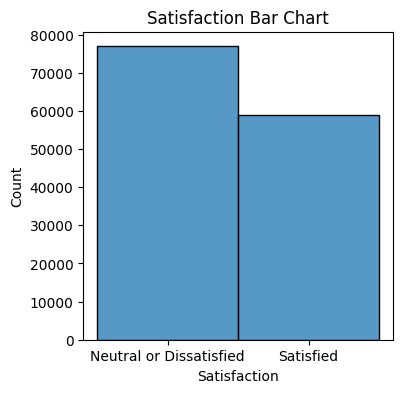

In [40]:
plt.figure(figsize=(4,4))
sns.histplot(df['Satisfaction'])
plt.title('Satisfaction Bar Chart')
plt.show()

,variable,staistic,pvalue,dof
0,Gender,15.991845,0.000064,1
1,Customer Type,4681.783635,0.000000,1
2,Type of Travel,27573.027960,0.000000,1
3,Class,34495.263974,0.000000,2


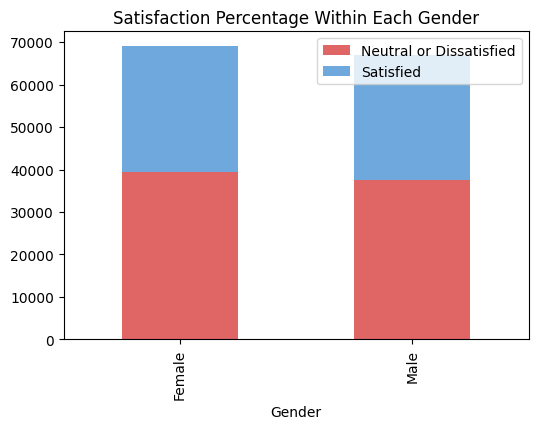

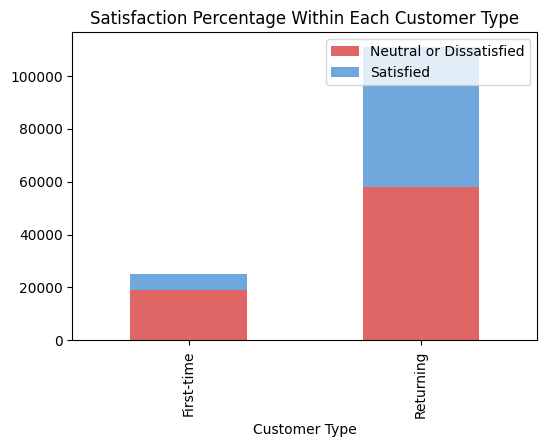

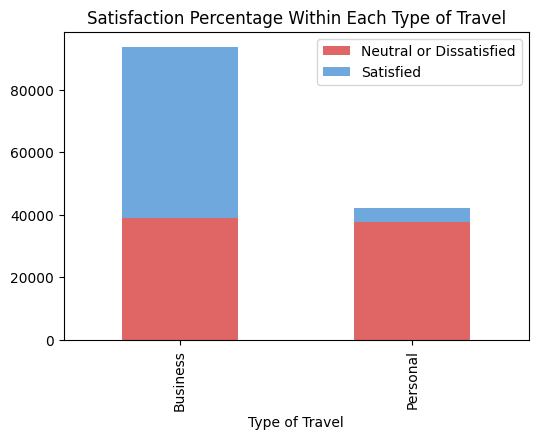

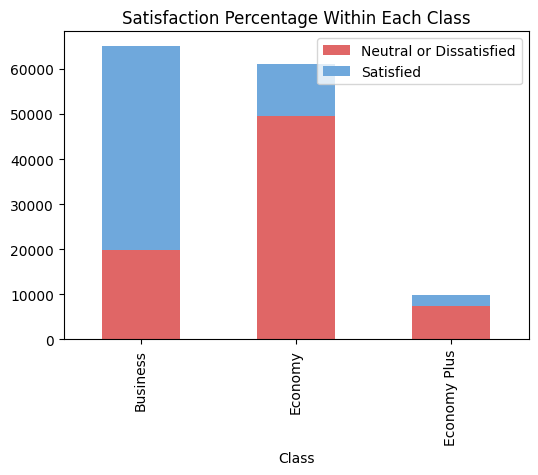

In [41]:
#Relationship between Categorial Features and Target
categoricl_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
results_list = []
for col in categoricl_columns:
    contingency_table = pd.crosstab(df[col], df['Satisfaction'])
    contingency_table.plot(kind='bar',stacked=True, figsize=(6,4), color=['#e06666', '#6fa8dc'])
    plt.title(f'Satisfaction Percentage Within Each {col}')
    plt.legend(loc='upper right')
    results = chi2_contingency(contingency_table)
    results_list.append({
        'variable': col,
        'staistic':results.statistic,
        'pvalue': results.pvalue,
        'dof': results.dof
    })
results_df = pd.DataFrame(results_list)
display(results_df)

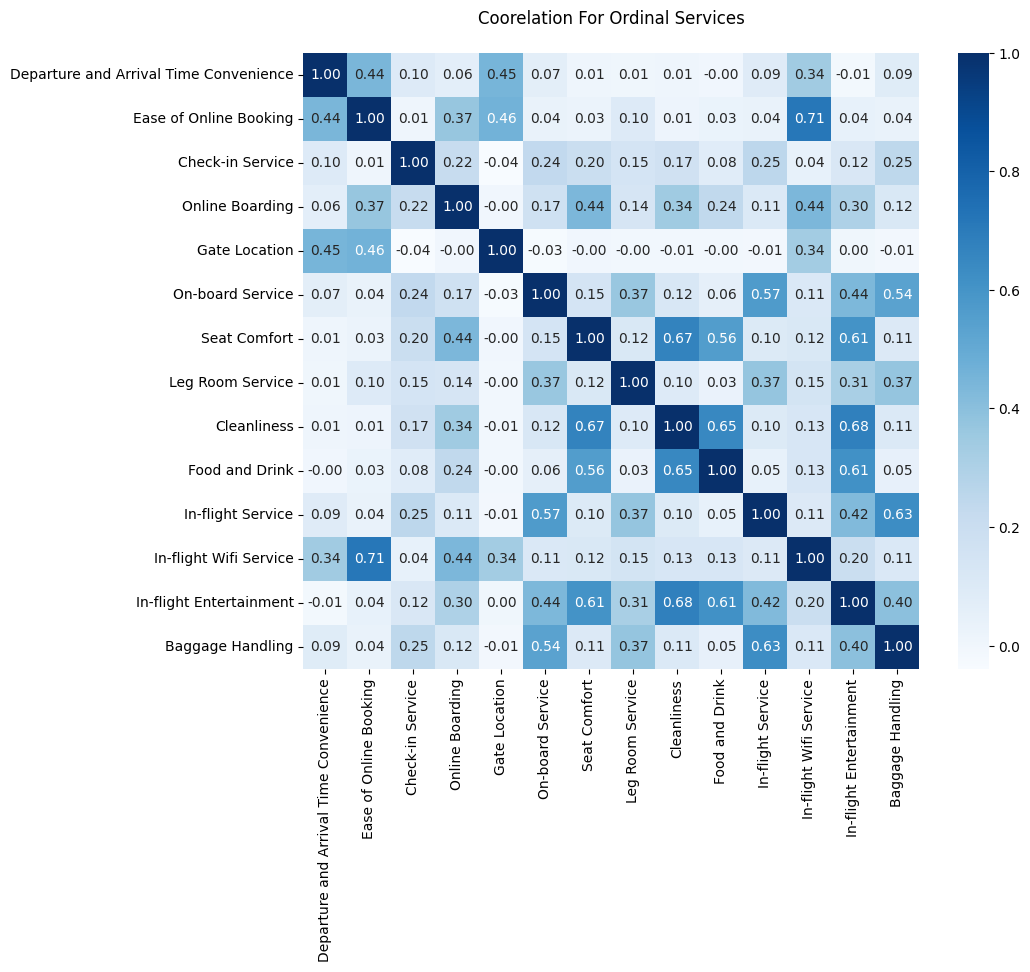

In [46]:
#Correlation between Ordinal Features
ordinarily_columns = ['Departure and Arrival Time Convenience','Ease of Online Booking',
                      'Check-in Service','Online Boarding','Gate Location','On-board Service',
                      'Seat Comfort','Leg Room Service','Cleanliness','Food and Drink','In-flight Service',
                      'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling'
]
ordinarily_correlation = df[ordinarily_columns].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(ordinarily_correlation, annot=True,fmt='.2f',cmap='Blues',square=True)
plt.title('Coorelation For Ordinal Services\n')
plt.show()

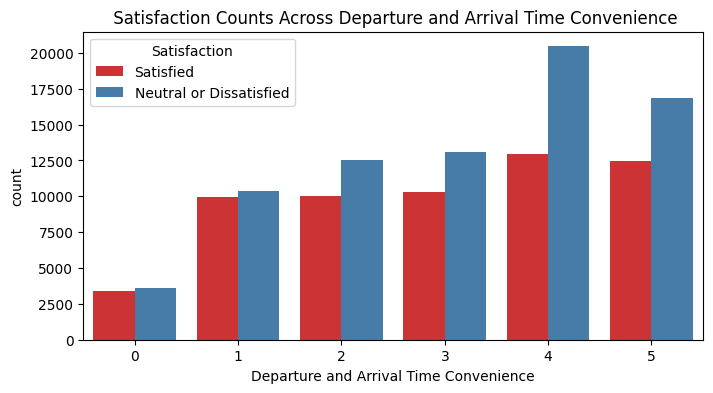

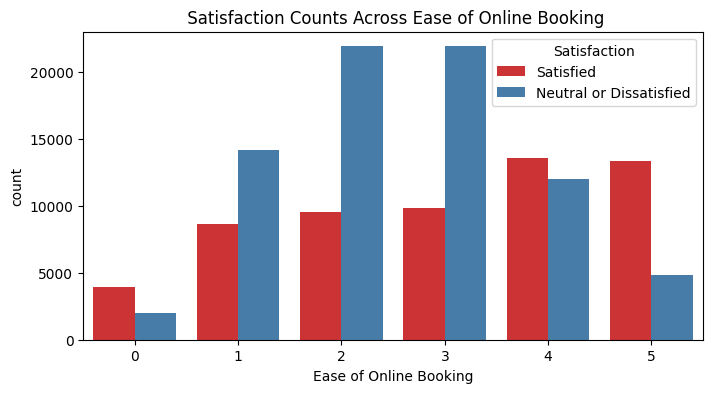

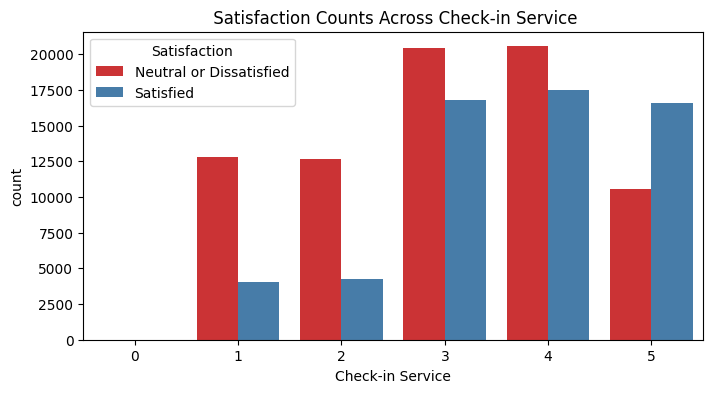

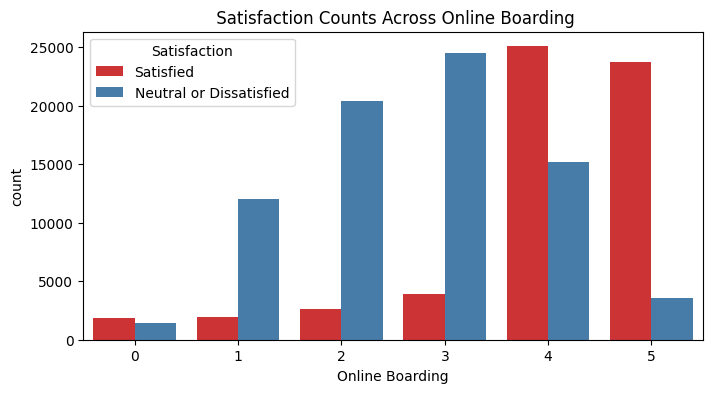

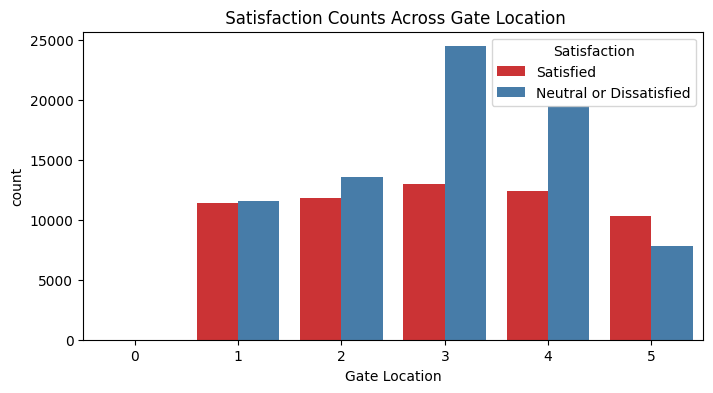

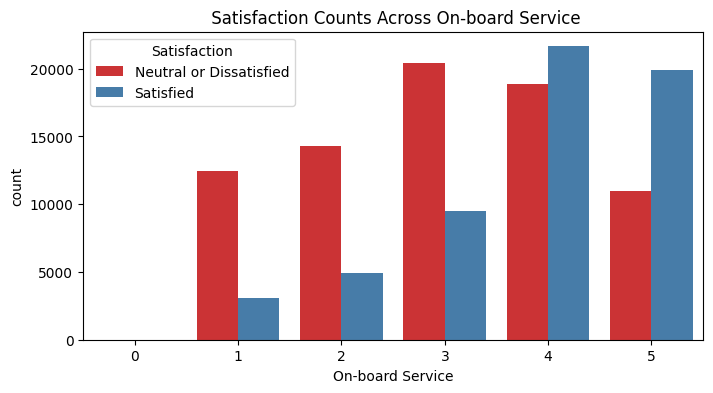

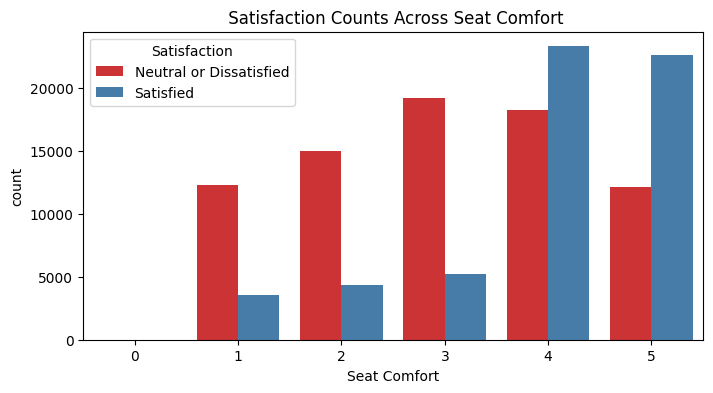

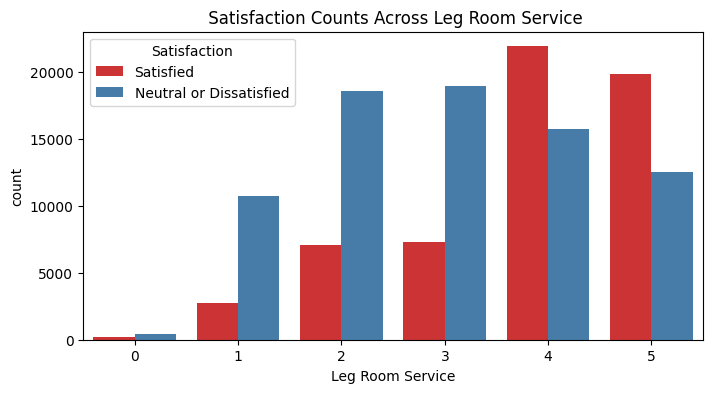

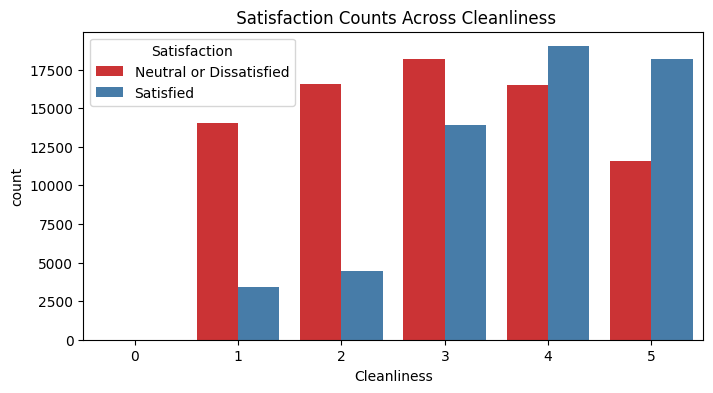

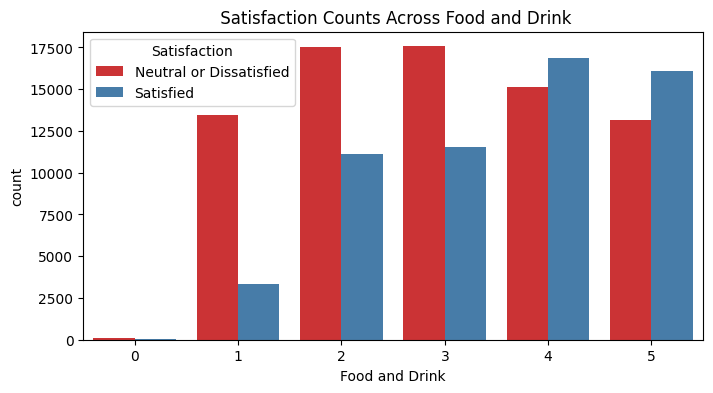

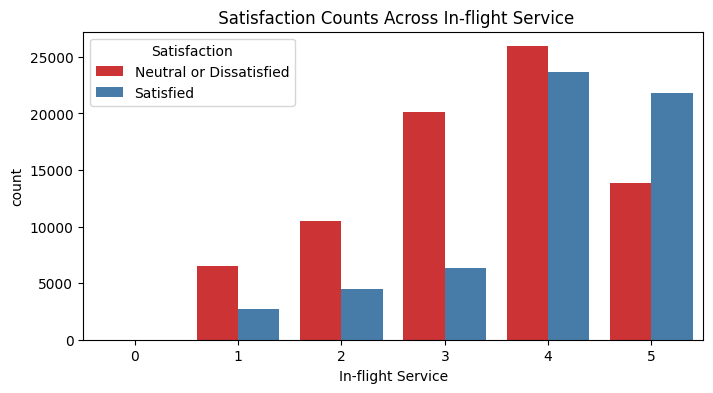

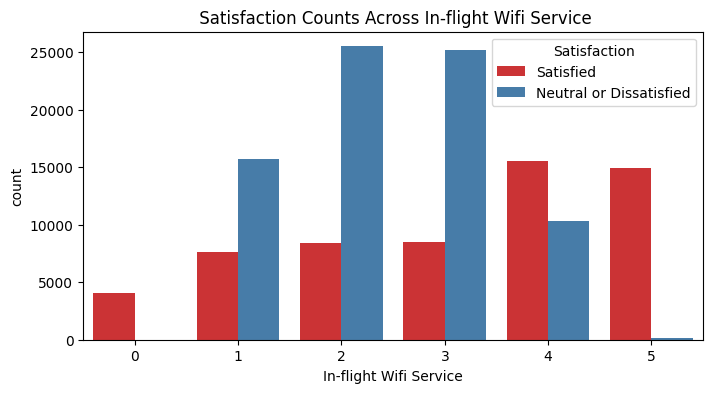

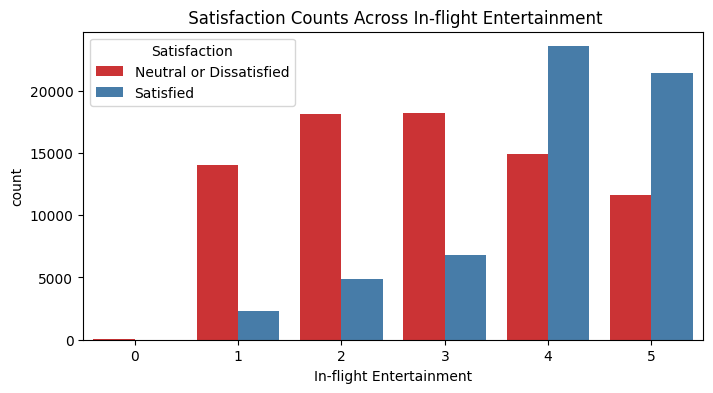

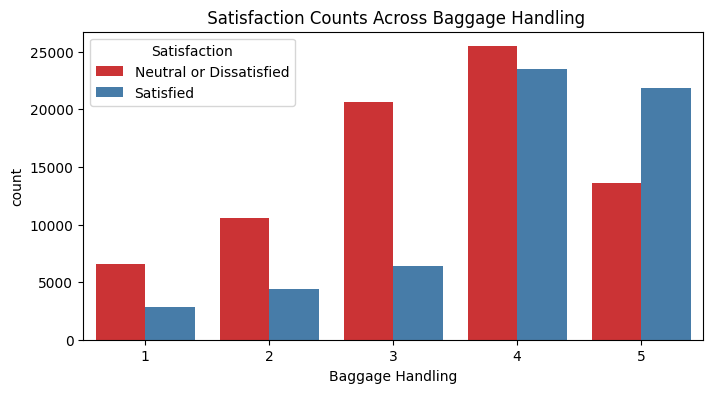

In [49]:
for col in ordinarily_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Satisfaction', data=df, palette='Set1')
    plt.title(f' Satisfaction Counts Across {col}')
    plt.show()

In [50]:
df['Satisfaction'].value_counts()

Satisfaction
Neutral or Dissatisfied    76923
Satisfied                  59036
Name: count, dtype: int64

In [51]:
#Convert 'Satisfaction' column into 0 and 1
df['numeric_Satisfaction'] = df['Satisfaction'].map({'Satisfied':1,'Neutral or Dissatisfied':0})
df['numeric_Satisfaction'].value_counts()

numeric_Satisfaction
0    76923
1    59036
Name: count, dtype: int64

In [52]:
#Calculate the Correlation between ordinarly features and target
target_ordinarily_correlation = df[ordinarily_columns].corrwith(df['numeric_Satisfaction'], method='spearman')
target_ordinarily_correlation

Departure and Arrival Time Convenience   -0.052569
Ease of Online Booking                    0.174660
Check-in Service                          0.233267
Online Boarding                           0.549893
Gate Location                            -0.003754
On-board Service                          0.327472
Seat Comfort                              0.361239
Leg Room Service                          0.316936
Cleanliness                               0.304475
Food and Drink                            0.208705
In-flight Service                         0.265437
In-flight Wifi Service                    0.286899
In-flight Entertainment                   0.398913
Baggage Handling                          0.270044
dtype: float64

In [53]:
target_ordinarily_correlation_df = target_ordinarily_correlation.reset_index()
target_ordinarily_correlation_df.columns = ['Services', 'Correlation with Satisfaction']
target_ordinarily_correlation_df = target_ordinarily_correlation_df.sort_values(by='Correlation with Satisfaction', ascending=False)
target_ordinarily_correlation_df

,Services,Correlation with Satisfaction
3,Online Boarding,0.549893
12,In-flight Entertainment,0.398913
6,Seat Comfort,0.361239
5,On-board Service,0.327472
7,Leg Room Service,0.316936
8,Cleanliness,0.304475
11,In-flight Wifi Service,0.286899
13,Baggage Handling,0.270044
10,In-flight Service,0.265437
2,Check-in Service,0.233267


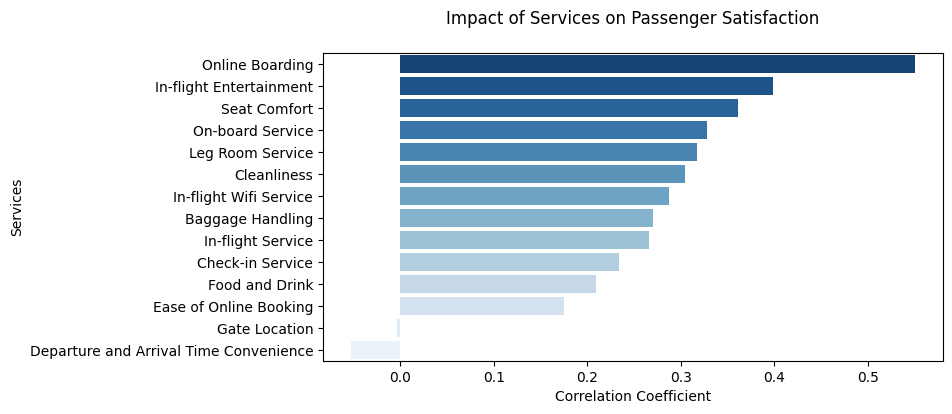

In [55]:
plt.figure(figsize=(8,4))
sns.barplot(
    x='Correlation with Satisfaction',
    y='Services', 
    data=target_ordinarily_correlation_df,
    palette='Blues_r',
    hue='Services',
    legend=False
)
plt.title('Impact of Services on Passenger Satisfaction\n')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Services')
plt.show()

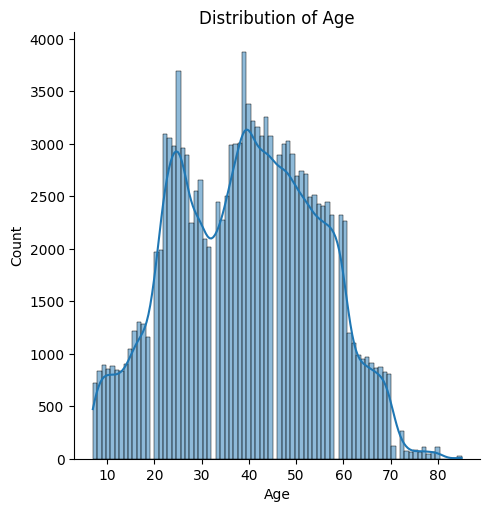

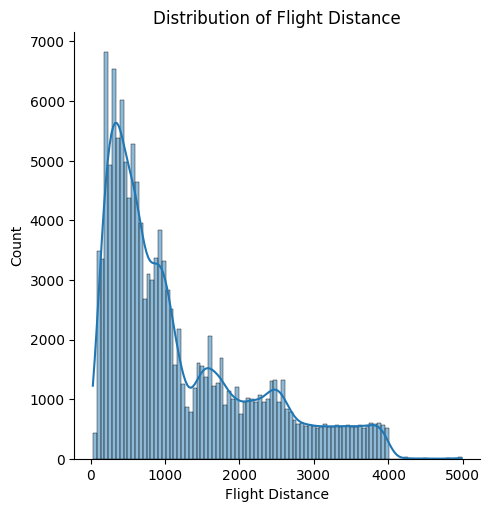

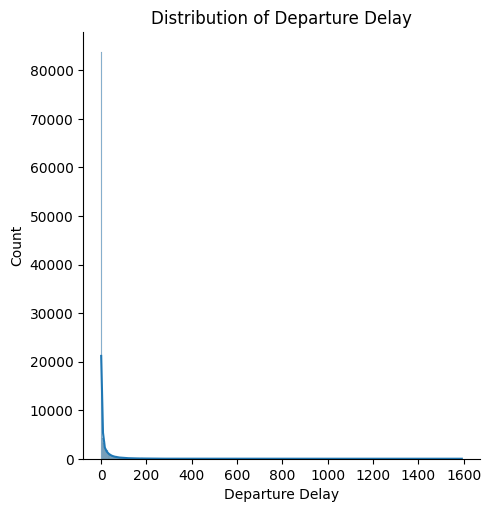

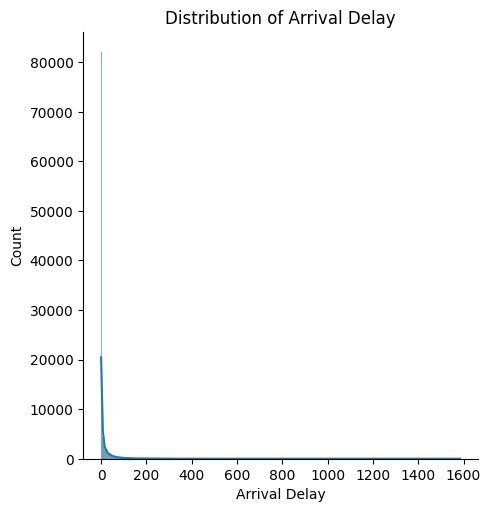

In [56]:
continuous_col = ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']
for col in continuous_col:
    sns.displot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

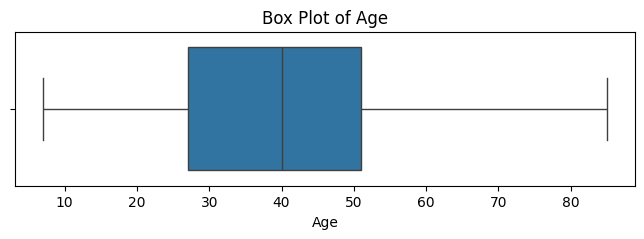

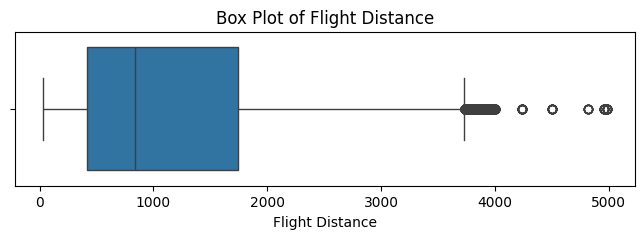

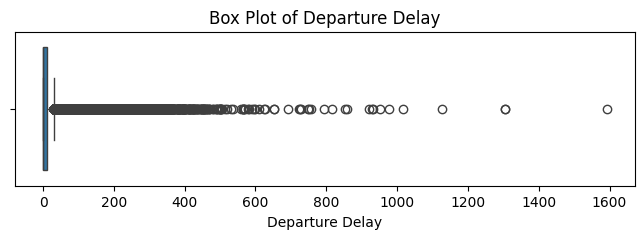

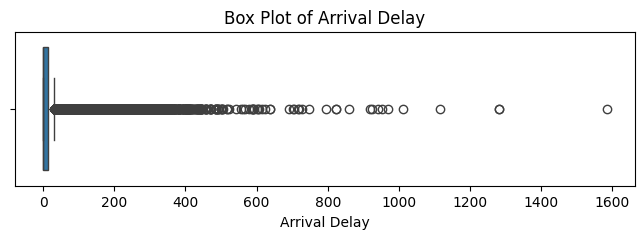

In [57]:
for col in continuous_col:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

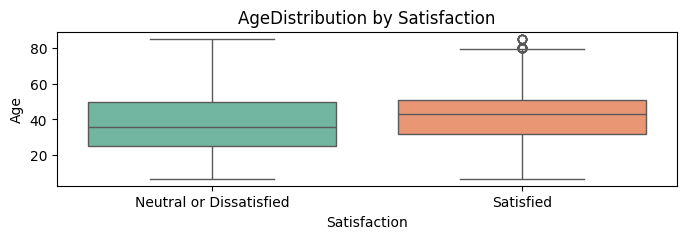

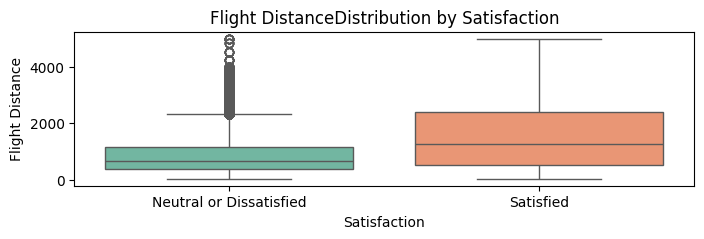

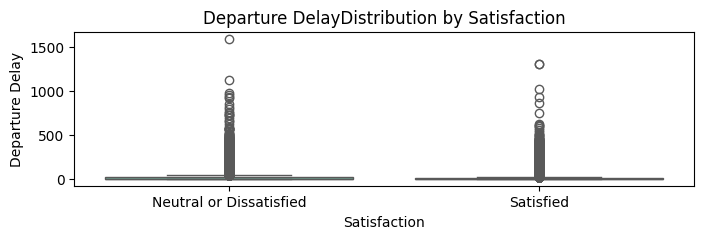

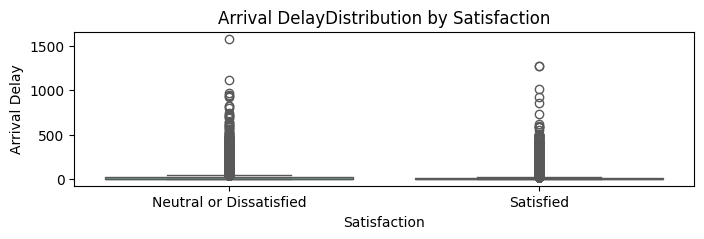

In [58]:
for col in continuous_col:
    plt.figure(figsize=(8,2))
    sns.boxplot(x='Satisfaction', y=col, data=df, palette='Set2', hue='Satisfaction', legend=False)
    plt.title(f'{col}Distribution by Satisfaction')
    plt.show()

In [59]:
#Continuous variables and Target

satisfied = df[df['numeric_Satisfaction'] == 1]
dissatisfied = df[df['numeric_Satisfaction'] == 0]

results2_list = []
for col in continuous_col:
    mean_satisfied = df[df['numeric_Satisfaction'] == 1][col].mean()
    mean_dissatisfied = df[df['numeric_Satisfaction'] == 0][col].mean()
    results2 = mannwhitneyu(satisfied[col], dissatisfied[col])
    results2_list.append({
        'Variable': col,
        'Statistic': results2.statistic,
        'P_value': results2.pvalue,
        'Mean Satisfied': mean_satisfied,
        'Mean Dissatisfied': mean_dissatisfied
    })
results2_df = pd.DataFrame(results2_list)
results2_df

,Variable,Statistic,P_value,Mean Satisfied,Mean Dissatisfied
0,Age,2.651613e+09,0.000000e+00,41.734603,37.637287
1,Flight Distance,2.948676e+09,0.000000e+00,1527.972356,927.921792
2,Departure Delay,2.106333e+09,2.976304e-141,12.464835,16.343395
3,Arrival Delay,2.028439e+09,2.472235e-303,12.554729,17.061659


## Part 2: Data Preprocessing
* Explain your strategy for handling categorical variables (e.g., One-Hot Encoding vs Label Encoding) and missing data.  
**Crucial:** Remember to split your data into training and testing sets BEFORE applying scaling to prevent data leakage.

In [74]:
columns_to_drop = ['ID', 'Gender', 'Satisfaction', 'Gate Location']
df_cleaned = df.drop(columns= columns_to_drop, errors='ignore')
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 135959 entries, 0 to 136373
Data columns (total 21 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Age                                     135959 non-null  int64
 1   Customer Type                           135959 non-null  str  
 2   Type of Travel                          135959 non-null  str  
 3   Class                                   135959 non-null  str  
 4   Flight Distance                         135959 non-null  int64
 5   Departure Delay                         135959 non-null  int64
 6   Arrival Delay                           135959 non-null  int64
 7   Departure and Arrival Time Convenience  135959 non-null  int64
 8   Ease of Online Booking                  135959 non-null  int64
 9   Check-in Service                        135959 non-null  int64
 10  Online Boarding                         135959 non-null  int64
 11  On-board Service

In [75]:
type(df_cleaned)

pandas.DataFrame

In [76]:
df_cleaned['Type of Travel'].value_counts()

Type of Travel
Business    93847
Personal    42112
Name: count, dtype: int64

In [77]:
df_cleaned['Customer_Type_Numeric'] = df_cleaned['Customer Type'].map({'Returning': 1, 'First-time': 0})
df_cleaned['Type_of_Travel_Numeric'] = df_cleaned['Type of Travel'].map({'Business': 1, 'Personal': 0})
df_cleaned = df_cleaned.drop(columns=['Customer Type', 'Type of Travel'])
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 135959 entries, 0 to 136373
Data columns (total 21 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Age                                     135959 non-null  int64
 1   Class                                   135959 non-null  str  
 2   Flight Distance                         135959 non-null  int64
 3   Departure Delay                         135959 non-null  int64
 4   Arrival Delay                           135959 non-null  int64
 5   Departure and Arrival Time Convenience  135959 non-null  int64
 6   Ease of Online Booking                  135959 non-null  int64
 7   Check-in Service                        135959 non-null  int64
 8   Online Boarding                         135959 non-null  int64
 9   On-board Service                        135959 non-null  int64
 10  Seat Comfort                            135959 non-null  int64
 11  Leg Room Service

In [78]:
df['Class'].value_counts()

Class
Business        65070
Economy         61072
Economy Plus     9817
Name: count, dtype: int64

In [ ]:
df_cleaned['Class_Business'] = (df_cleaned['Class'] == 'Business').astype(int)

In [ ]:
# Your preprocessing, train_test_split, and scaling code here

# Note: you are not required to answer in this single cell, create more cells if needed


## Part 3: Modeling
* Train your models.

In [ ]:
# Model 1 Training & Prediction
# Note: you are not required to answer in this single cell, create more cells if needed



In [ ]:
# Model 2 Training & Prediction
# Note: you are not required to answer in this single cell, create more cells if needed


## Part 4: Evaluation
* Output the classification reports and confusion matrices for all models.

In [ ]:
# Evaluation metrics
# Note: you are not required to answer in this single cell, create more cells if needed


## Part 5: Final Comparative Analysis
*(Double click this cell to edit)*

**Write your final conclusions here:**
Which model performed best according to your metrics, and why do you think that is?
